In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
from scipy import signal
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from matplotlib.ticker import FormatStrFormatter

# データの読み込み

## 歩行軌跡と歩行速度

In [20]:
trajectory_file_path ="../../../input/demo/take4_4Hz.csv"
speed_file_path = "speed.csv"

# 通信してデータを取得
df_trajectory = pd.read_csv(trajectory_file_path)
df_speed = pd.read_csv(speed_file_path)

## データの描画

### 歩行軌跡

<Figure size 640x480 with 0 Axes>

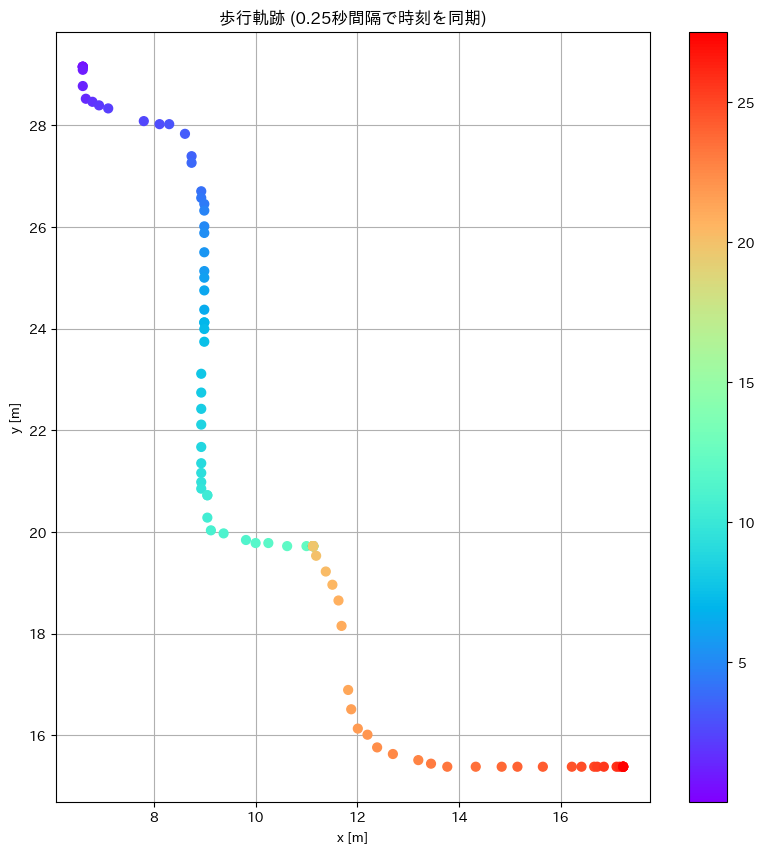

In [21]:
plt.subplots_adjust(hspace=0.3)
fig = plt.figure(figsize=(10, 10))

x = df_trajectory['x']
y = df_trajectory['y'] 
time = df_trajectory['time']

# 補間された軌跡を描画
plt.colorbar(plt.scatter(x, y,c=time,cmap='rainbow',s=40, label=f'推定軌跡', zorder=2))

plt.gca().set_aspect('equal', adjustable='box')
plt.title('歩行軌跡 (0.25秒間隔で時刻を同期)')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.grid(True)

plt.show()


## 滞在中っぽい座標を赤くする
### speedが滞在中ぽい場所をtimeで指定

<Figure size 640x480 with 0 Axes>

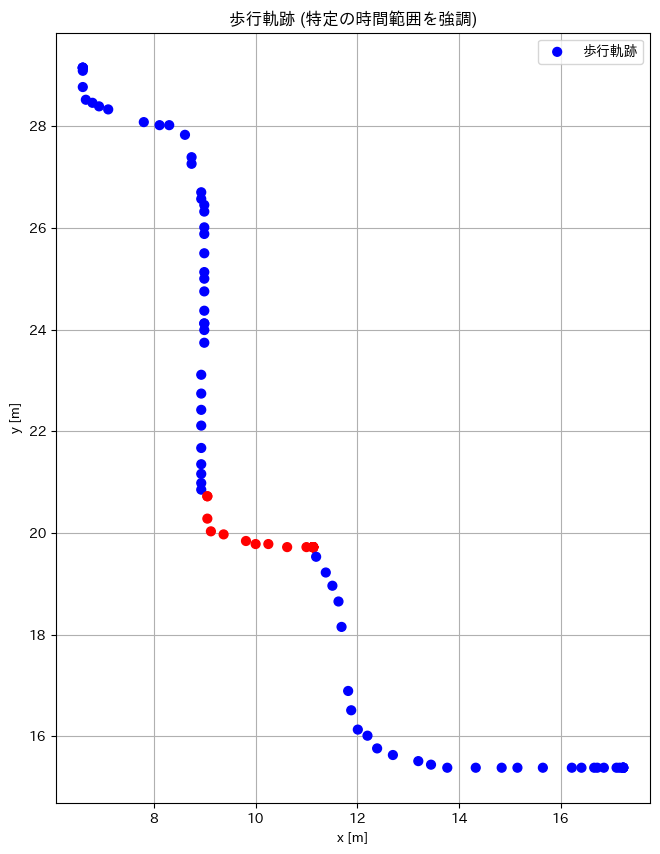

In [22]:
# timeが15秒から27秒の範囲にあるかどうかで色を決定
colors = np.where((df_trajectory['time'] >= 10) & (df_trajectory['time'] <= 20), 'red', 'blue')


plt.subplots_adjust(hspace=0.3)
fig = plt.figure(figsize=(10, 10))

# 特定の時間範囲の点を強調（例：赤色）
plt.scatter(df_trajectory['x'], df_trajectory['y'], c=colors, s=40, label='歩行軌跡', zorder=2)


plt.gca().set_aspect('equal', adjustable='box')
plt.title('歩行軌跡 (特定の時間範囲を強調)')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.grid(True)
plt.legend() # ラベルを表示するために凡例を追加
plt.show()

### 歩行速度

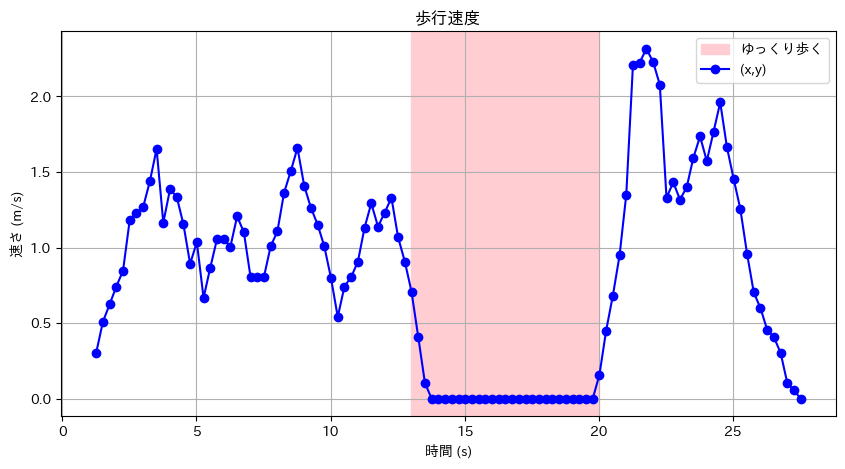

In [23]:
# ~speed.csvに1行目にデータ_足す(time,speed)[1]=(?,0)
# 軌跡と速度のtimeを同期するため
speed = df_speed['low_speed'] 
time = df_speed['time']
plt.figure(figsize=(10, 5))
plt.axvspan(13.0, 20.0,alpha=1.0,color="#ffcdd2",label='ゆっくり歩く')
plt.plot(time,speed, marker='o', linestyle='-', color='blue', label='(x,y)')
plt.xlabel('時間 (s)')
plt.ylabel('速さ (m/s)')
plt.title('歩行速度')
plt.grid(True)
plt.legend()

plt.show()

# データのラベル付け/抽出ロジック

       time      x      y     speed   stay
0     0.014   6.60  29.15       NaN  False
1     0.266   6.60  29.15  0.000000   True
2     0.514   6.60  29.15  0.000000   True
3     0.764   6.60  29.15  0.000000   True
4     1.015   6.60  29.09  0.239044   True
..      ...    ...    ...       ...    ...
106  26.515  17.23  15.38  0.000000   True
107  26.765  17.23  15.38  0.000000   True
108  27.015  17.23  15.38  0.000000   True
109  27.265  17.23  15.38  0.000000   True
110  27.515  17.23  15.38  0.000000   True

[111 rows x 5 columns]
赤(滞留)になる数: 43
青(移動)になる数: 67


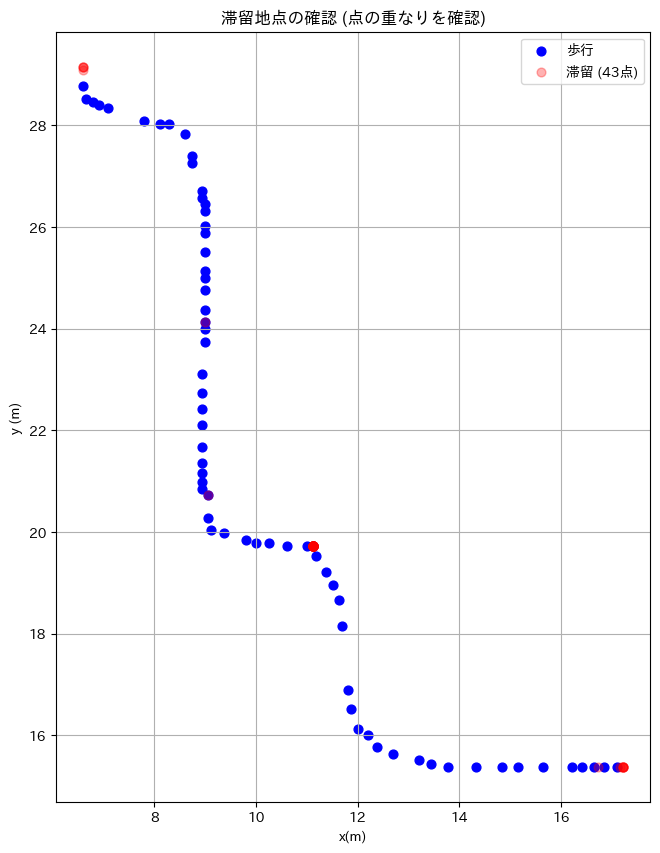

In [24]:
# 時間軸での同期: 歩行軌跡データと歩行速度データは、同じ時間点に対応しているか
df_trajectory = pd.merge(df_trajectory, df_speed[['time', 'speed']], on='time', how='left')

# 閾値の設定
# 条件判定: 歩行速度が設定された閾値以下であるか
threshold = 0.5
df_trajectory['stay'] = df_trajectory['speed'] <= threshold

print(df_trajectory)
df_trajectory.to_csv('threshold_trajectory_data.csv', index=False)

red_count = (df_trajectory['speed'] <= threshold).sum()
blue_count = (df_trajectory['speed'] > threshold).sum()
print(f"赤(滞留)になる数: {red_count}")
print(f"青(移動)になる数: {blue_count}")


plt.figure(figsize=(10, 10))

# データを分割して描画することで、「確実に赤を上に」表示させます
df_stay = df_trajectory[df_trajectory['speed'] <= threshold]
df_walk = df_trajectory[df_trajectory['speed'] > threshold]

# 1. 青（移動）を先に描画（背面）

plt.scatter(df_walk['x'], df_walk['y'], c='blue', s=40, label='歩行', zorder=1)

# 2. 赤（滞留）を後に描画（手前）

plt.scatter(df_stay['x'], df_stay['y'], c='red', s=40, label=f'滞留 ({red_count}点)', zorder=2, alpha=0.3)

plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('x(m)')
plt.ylabel('y (m)')
plt.title(f'滞留地点の確認 (点の重なりを確認)')
plt.grid(True)
plt.legend()
plt.show()